Theta (Normal Equation):
 [[4.21509616]
 [2.77011339]]


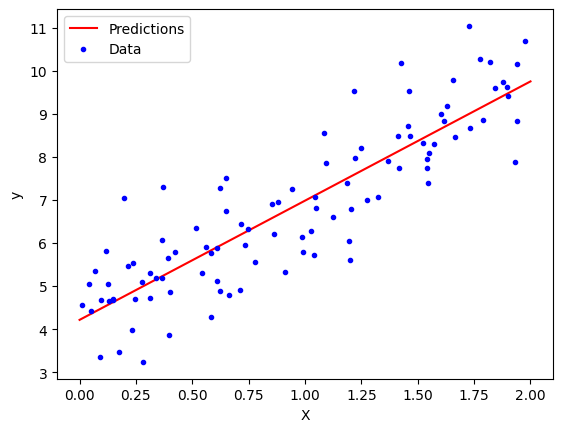

LinearRegression coef_ and intercept_: [[2.77011339]] [4.21509616]
Predictions (Scikit-learn): [[4.21509616]
 [9.75532293]]
Theta (Gradient Descent):
 [[4.21509616]
 [2.77011339]]
Theta (Stochastic Gradient Descent):
 [[4.18475289]
 [2.73036719]]
SGDRegressor coef_ and intercept_: [2.77853398] [4.21647744]


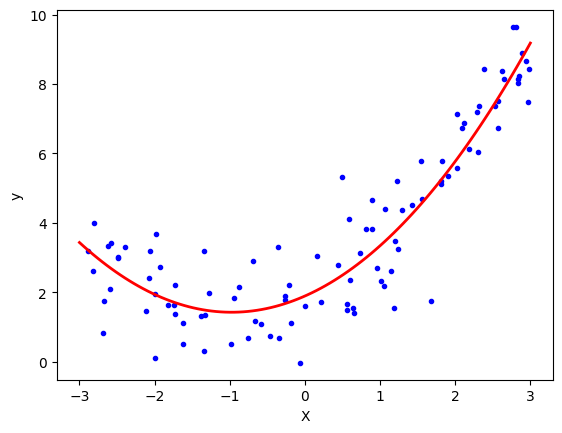

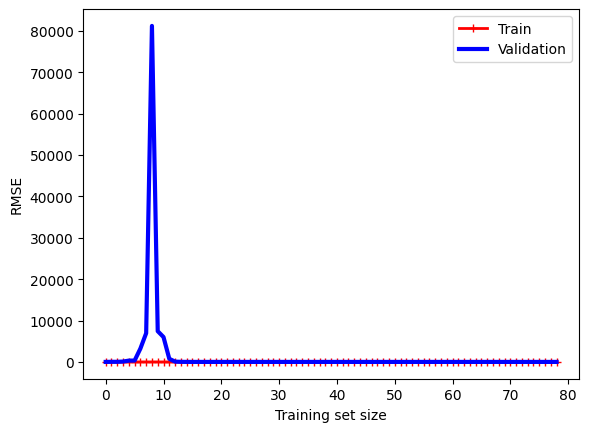

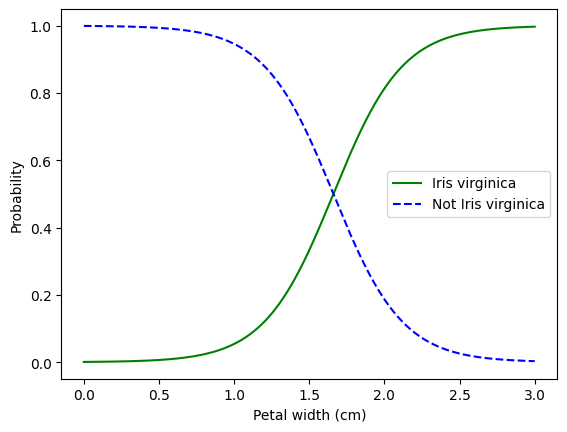

Softmax prediction: [2]
Softmax probabilities: [[6.21626374e-07 5.73689802e-02 9.42630398e-01]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [43]:
# Install dependencies (opsional, biasanya sudah ada di Colab)
# !pip install numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Generate linear data for Linear Regression example
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term for Normal Equation
X_b = np.c_[np.ones((100, 1)), X]

# Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("Theta (Normal Equation):\n", theta_best)

# Predictions
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)

# Plot Linear Regression
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Using Scikit-Learn's LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("LinearRegression coef_ and intercept_:", lin_reg.coef_, lin_reg.intercept_)
print("Predictions (Scikit-learn):", lin_reg.predict(X_new))

########################################
# Gradient Descent Implementation
########################################
eta = 0.1
n_iterations = 1000
m = 100
theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

print("Theta (Gradient Descent):\n", theta)

########################################
# Stochastic Gradient Descent (manual)
########################################
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

print("Theta (Stochastic Gradient Descent):\n", theta)

########################################
# Using SGDRegressor (Scikit-learn)
########################################
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
print("SGDRegressor coef_ and intercept_:", sgd_reg.coef_, sgd_reg.intercept_)

########################################
# Polynomial Regression
########################################
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(m, 1)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_trans = poly_features.fit_transform(X_poly)

lin_reg = LinearRegression()
lin_reg.fit(X_poly_trans, y_poly)

# Plot Polynomial Regression
X_plot = np.linspace(-3, 3, 100).reshape(100, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)

plt.plot(X_poly, y_poly, "b.")
plt.plot(X_plot, y_plot, "r-", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

########################################
# Learning Curves Function
########################################
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation")
    plt.legend()
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.show()

# Example: Polynomial Regression degree=10
polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin_reg", LinearRegression())
])
plot_learning_curves(polynomial_regression, X_poly, y_poly)

########################################
# Regularization (Ridge, Lasso, ElasticNet)
########################################
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X_poly_trans, y_poly)

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_poly_trans, y_poly)

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_poly_trans, y_poly)

########################################
# Logistic Regression (Binary Classification)
########################################
from sklearn import datasets
iris = datasets.load_iris()
X = iris["data"][:, 3:]  # petal width
y = (iris["target"] == 2).astype(np.int32)

log_reg = LogisticRegression()
log_reg.fit(X, y)

# Plot probabilities
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend()
plt.show()

########################################
# Softmax Regression (Multiclass Classification)
########################################
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)
softmax_reg.fit(X, y)
print("Softmax prediction:", softmax_reg.predict([[5, 2]]))
print("Softmax probabilities:", softmax_reg.predict_proba([[5, 2]]))

# 📚 Hands-On Machine Learning - Chapter 4
## 🏷️ *Training Models*

---

## 🔸 1. Linear Regression
Model memprediksi nilai target sebagai fungsi linier dari fitur:

**Persamaan umum Linear Regression:**

\[
\hat{y} = \theta_0 + \theta_1x_1 + \cdots + \theta_nx_n
\]

**Bentuk vektor:**

\[
\hat{y} = \theta^T x
\]

---

### 🔧 Training Linear Regression
1. **Normal Equation (Closed Form):**
   
\[
\theta = (X^T X)^{-1} X^T y
\]

2. **Gradient Descent (GD):**

\[
\theta = \theta - \eta \cdot \nabla_\theta MSE(\theta)
\]

- η = learning rate
- Terdapat **Batch GD**, **Stochastic GD (SGD)**, **Mini-batch GD**

**Penting:** Data perlu **Feature Scaling** agar Gradient Descent konvergen lebih cepat.

---

## 🔸 2. Polynomial Regression
Linear Regression dengan menambahkan fitur polinomial agar dapat memodelkan hubungan non-linear.

**Contoh fitur:** \([x, x^2, x^3, ...]\)

**Masalah:** Mudah *overfitting*, perlu regularisasi.

---

## 🔸 3. Learning Curves
Grafik **RMSE** terhadap ukuran data:

- **Underfitting:** Train error & Validation error tinggi → model terlalu sederhana.
- **Overfitting:** Train error rendah, Validation error tinggi → model terlalu kompleks.

---

## 🔸 4. Regularization
Menambahkan penalti untuk membatasi besar koefisien model:

1. **Ridge Regression (L2):**

\[
J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2
\]

2. **Lasso Regression (L1):**

\[
J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|
\]

3. **Elastic Net:** Gabungan L1 dan L2

---

## 🔸 5. Early Stopping
Menghentikan proses training **sebelum overfitting** terjadi. Stop training saat error di validation set mulai meningkat.

---

## 🔸 6. Logistic Regression (Binary Classification)
Menghitung probabilitas dengan fungsi **sigmoid**:

\[
p = \frac{1}{1 + e^{-(\theta^T x)}}
\]

**Fungsi Loss (Log Loss):**

\[
J(\theta) = -\frac{1}{m} \sum_{i=1}^m \Big( y_i \log(p_i) + (1-y_i)\log(1-p_i) \Big)
\]

---

## 🔸 7. Softmax Regression (Multiclass Classification)
Menghitung probabilitas tiap kelas:

\[
p_k = \frac{e^{s_k(x)}}{\sum_{j=1}^K e^{s_j(x)}}
\]
Dengan:

\[
s_k(x) = \theta_k^T x
\]

**Loss function: Cross-Entropy**

---

## ⚖️ Bias-Variance Trade-off
| **Bias Tinggi**  | **Variance Tinggi** |
|------------------|---------------------|
| Model terlalu sederhana → Underfitting | Model terlalu kompleks → Overfitting |

---

## ✅ Kesimpulan
- Linear Regression → untuk regresi linear
- Polynomial Regression → untuk data non-linear
- Regularisasi → mencegah overfitting
- Logistic Regression → klasifikasi biner
- Softmax Regression → klasifikasi multi-kelas
- Early Stopping & Feature Scaling → mempercepat training & mencegah overfitting
